Using the default year of 2021
Using FIPS code '29' for input 'MO'


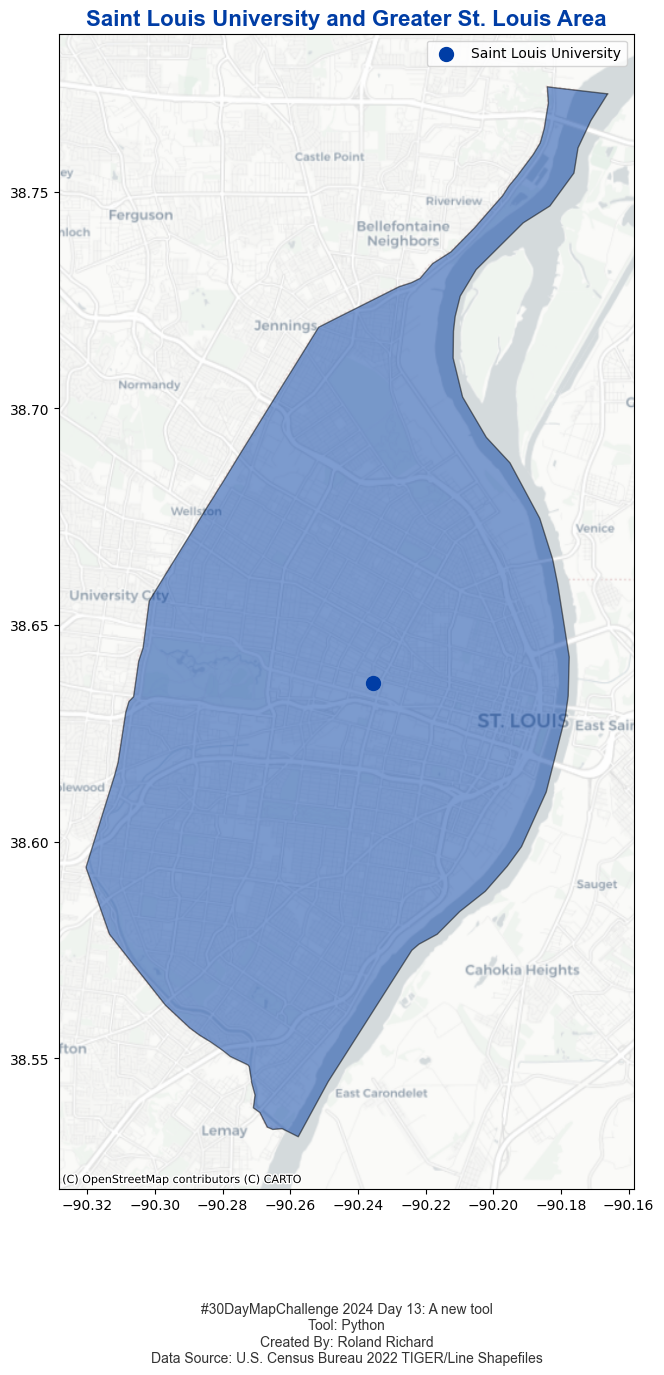

In [11]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import contextily as ctx
import folium
import os
from pygris import places
from IPython.display import IFrame, display

# Load geospatial data using pygris
try:
    # Load St. Louis place boundaries using pygris
    stl_metro = places(state='MO', cb=True)
    stl_metro = stl_metro[stl_metro['NAME'].str.contains('St. Louis') & ~stl_metro['NAME'].str.contains('Lake St. Louis')]
    # Reproject the data to the appropriate coordinate system
    stl_metro = stl_metro.to_crs(epsg=4326)
except Exception as e:
    print(f"Error: {e}. Please check your inputs or network connection.")
    stl_metro = None

# Create GeoDataFrame for Saint Louis University (SLU) location
slu_coordinates = [(-90.2355, 38.6366)]  # Longitude, Latitude of SLU
slu_gdf = gpd.GeoDataFrame(geometry=[Point(lon, lat) for lon, lat in slu_coordinates], crs="EPSG:4326")

# Ensure the metro data was loaded before continuing
if stl_metro is not None:
    # Plotting St. Louis Metro and SLU
    fig, ax = plt.subplots(figsize=(15, 15))
    ax.set_title('Saint Louis University and Greater St. Louis Area', fontsize=16, fontweight='bold', color='#003DA5', family='Arial')
    
    stl_metro.plot(ax=ax, alpha=0.5, edgecolor='k', color='#003DA5')  # SLU Blue
    slu_gdf.plot(ax=ax, color='#003DA5', markersize=100, label='Saint Louis University')
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs='EPSG:4326', zoom=12)
    ax.text(
        0.5, -0.15,
        "#30DayMapChallenge 2024 Day 13: A new tool\nTool: Python\nCreated By: Roland Richard\nData Source: U.S. Census Bureau 2022 TIGER/Line Shapefiles",
        ha='center', fontsize=10, color='#333333', family='Arial', transform=ax.transAxes)
    ax.legend()
    plt.savefig('st_louis_static_map.png', dpi=300, format='png', bbox_inches='tight')
    
    plt.show()

    # Creating an interactive map with folium
    m = folium.Map(location=[38.6366, -90.2355], zoom_start=13, tiles='CartoDB Positron')

    # Adding the SLU marker
    folium.Marker(
        location=[38.6366, -90.2355],
        popup='Saint Louis University'
    ).add_to(m)

    # Adding the St. Louis Metro area boundary to the folium map
    folium.GeoJson(
        stl_metro.to_json(),
        name='Greater St. Louis Area',
        style_function=lambda x: {'color': '#003DA5', 'weight': 2, 'fillColor': '#C99700', 'fillOpacity': 0.1}
    ).add_to(m)

    # Displaying the map
    m.save('st_louis_map.html')
    display(IFrame('st_louis_map.html', width=700, height=500))
else:
    print("Could not load St. Louis metro data. Please update the source or use a local file.")
